# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402123
- 姓名：陈梓豪
- GitHub 仓库链接：
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告基于福州二手房房源数据集（`ershoufang_list.csv`，共 11,856 条房源记录），围绕福州二手房市场的价格分布、区域差异、户型结构等核心问题展开系统分析。

分析过程中，首先对原始数据进行了质量检查和数据清洗——从带有单位（㎡、万、元/㎡）和混合格式的原始文本字段中，
使用正则表达式提取面积、总价、均价、建造年份、户型结构、楼层信息等数值变量；随后使用 `pandas` 和 `numpy` 进行描述性统计、分组聚合和交叉分析；
最后使用 `matplotlib` 和 `seaborn` 绘制了 6 张可视化图表，覆盖类别对比、数值分布、分组差异、双变量关系和房龄影响分析。

**主要发现**：
1. 福州二手房总价中位数为 173 万元，均价中位数为 18,326 元/㎡，价格分布呈明显右偏；
2. 鼓楼区均价（25,083 元/㎡）为全市最高，是外围区域的 3-5 倍，区域分化极其显著；
3. 3室2厅2卫户型占市场主导（41.9%），2-3室户型合计占比超 80%，市场以刚需和改善型需求为主；
4. 建筑面积与总价呈中等正相关（Pearson r=0.64），但均价随面积增大呈边际递减趋势；
5. 南北通透户型占市场 62.2%，老旧小区因地段优势出现"房龄与均价倒挂"现象。

## 2. 数据读取与分析目标

### 2.1 数据来源

本数据集为福州二手房房源爬取数据（来源：安居客），文件格式为 CSV（UTF-8 with BOM 编码），共 18 个字段，涵盖房源基本属性、价格信息和地理位置。

### 2.2 字段说明

| 字段 | 含义 | 原始格式 |
|---|---|---|
| `id` | 房源编号 | 整数 |
| `城市` | 城市拼音（fuzhou） | 文本 |
| `市区` | 房源所在市区（12个区） | 分类 |
| `标题` | 房源标题 | 文本 |
| `户型` | 房屋户型（如"3 室 2 厅 2 卫"） | 需解析 |
| `面积` | 房屋面积（如"103㎡"） | 需清洗 |
| `面积数值` | 预清洗面积数值 | float |
| `方位` | 房屋朝向 | 分类 |
| `楼层` | 楼层信息（如"中层(共31层)"） | 需解析 |
| `时间` | 建造时间（如"2025年建造"） | 需清洗 |
| `所属小区` | 小区名称 | 文本 |
| `所属区域` | 更具体的区域或地址信息 | 文本 |
| `房源链接` | 安居客房源URL | 文本 |
| `总价` | 房屋总价（如"199万"） | 需清洗 |
| `总价数值` | 预清洗总价数值 | float |
| `均价` | 每平方米价格（如"19321元/㎡"） | 需清洗 |
| `均价数值` | 预清洗均价数值 | float |
| `房龄` | 房龄分类标签（4类） | 分类 |

> 注：数据中虽存在 `面积数值`、`总价数值`、`均价数值` 三个预清洗数值字段，但为充分体现数据清洗能力，本报告从原始文本字段（`面积`、`总价`、`均价`）重新提取数值，并将提取结果与预清洗值进行交叉验证。

### 2.3 分析目标

本次分析围绕以下 7 个核心问题展开：

1. 福州二手房在各市区的分布情况如何？
2. 总价和均价的整体分布特征是什么？
3. 不同市区之间的房价水平有何差异？
4. 建筑面积与总价、均价的关系如何？
5. 户型结构呈现怎样的分布规律？
6. 建造年份/房龄对房价有何影响？
7. 朝向、楼层等因素是否显著影响房价？

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import re
import warnings
import sys
import os

warnings.filterwarnings('ignore', category=FutureWarning)

# ---------- 跨平台中文字体自动检测 ----------
# 策略：按操作系统优先级查找常见中文字体，无需任何外部文件
# 已执行 Notebook 中的图表输出为 PNG 像素数据，GitHub 上直接可见中文

PLATFORM_FONTS = {
    'win32':  ['Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi', 'FangSong', 'Microsoft JhengHei'],
    'darwin': ['PingFang SC', 'Heiti SC', 'STHeiti', 'STSong', 'Apple LiGothic', 'STKaiti'],
    'linux':  ['WenQuanYi Micro Hei', 'WenQuanYi Zen Hei', 'Noto Sans CJK SC',
               'Noto Sans SC', 'AR PL UMing CN'],
}

def find_cjk_font():
    """跨平台查找第一个可用的中文字体"""
    candidates = PLATFORM_FONTS.get(sys.platform, [])
    candidates += ['Arial Unicode MS', 'sans-serif']  # 通用后备
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            return font
    return None

# 必须：先调用 seaborn，再覆盖字体（seaborn 会重置 rcParams）
sns.set_theme(style='whitegrid')

CJK_FONT = find_cjk_font()
if CJK_FONT:
    plt.rcParams['font.sans-serif'] = [CJK_FONT]
    plt.rcParams['font.family'] = 'sans-serif'
    print(f'[OK] 中文字体: {CJK_FONT} (平台: {sys.platform})')
else:
    print('[WARN] 未找到中文字体，图表中文可能显示为方框。')
    print('       Linux 请: sudo apt install fonts-wqy-microhei')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

[OK] 中文字体: Microsoft YaHei (平台: win32)


In [2]:
# ---------- 读取数据 ----------
# 尝试多种编码，确保正确读取中文
for enc in ['utf-8-sig', 'utf-8', 'gbk', 'gb2312', 'gb18030']:
    try:
        df = pd.read_csv('ershoufang_list.csv', encoding=enc)
        print(f'✅ 成功读取，编码: {enc}')
        break
    except (UnicodeDecodeError, FileNotFoundError) as e:
        continue
else:
    raise RuntimeError('❌ 所有编码均无法读取，请检查文件。')

print(f'数据规模: {df.shape[0]} 行 × {df.shape[1]} 列')
print(f'字段列表: {list(df.columns)}')
df.head(5)

✅ 成功读取，编码: utf-8-sig
数据规模: 11856 行 × 18 列
字段列表: ['id', '城市', '市区', '标题', '户型', '面积', '面积数值', '方位', '楼层', '时间', '所属小区', '所属区域', '房源链接', '总价', '总价数值', '均价', '均价数值', '房龄']


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 3. 数据基本情况

以下展示数据规模、字段类型、样例数据，建立对数据的初步理解。

In [3]:
# ---------- 数据维度 ----------
print(f'样本量（行数）: {df.shape[0]:,}')
print(f'字段数（列数）: {df.shape[1]}')

样本量（行数）: 11,856
字段数（列数）: 18


In [4]:
# ---------- 字段名、数据类型、非空数量 ----------
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  str    
 2   市区      11856 non-null  str    
 3   标题      11856 non-null  str    
 4   户型      11856 non-null  str    
 5   面积      11856 non-null  str    
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  str    
 8   楼层      11856 non-null  str    
 9   时间      11856 non-null  str    
 10  所属小区    11856 non-null  str    
 11  所属区域    11856 non-null  str    
 12  房源链接    11856 non-null  str    
 13  总价      11830 non-null  str    
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  str    
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  str    
dtypes: float64(3), int64(1), str(14)
memory usage: 1.6 MB


In [5]:
# ---------- 查看每个字段的前几条唯一值，理解数据格式 ----------
for col in df.columns:
    print(f'\n--- {col} ---')
    print(f'  数据类型: {df[col].dtype}')
    print(f'  唯一值数: {df[col].nunique()}')
    # 展示前5个非空唯一值
    unique_vals = df[col].dropna().unique()[:5]
    for v in unique_vals:
        print(f'  → {repr(v)}')


--- id ---
  数据类型: int64
  唯一值数: 11856
  → np.int64(1)
  → np.int64(2)
  → np.int64(3)
  → np.int64(4)
  → np.int64(5)

--- 城市 ---
  数据类型: str
  唯一值数: 1
  → 'fuzhou'

--- 市区 ---
  数据类型: str
  唯一值数: 12
  → '台江'
  → '晋安'
  → '鼓楼'
  → '仓山'
  → '闽侯'

--- 标题 ---
  数据类型: str
  唯一值数: 9788
  → '近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万'
  → '来电可大刀  建发望樾盘精装3房 地铁口 低密宜居 精装好房'
  → '锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟'
  → '湖滨小隔壁十八中临近西次湖新房地铁4号线'
  → '保利招商和樾风华 3室2厅2卫'

--- 户型 ---
  数据类型: str
  唯一值数: 56
  → '3 室 2 厅 2 卫'
  → '3 室 2 厅 1 卫'
  → '2 室 1 厅 1 卫'
  → '2 室 2 厅 1 卫'
  → '4 室 2 厅 2 卫'

--- 面积 ---
  数据类型: str
  唯一值数: 3405
  → '103㎡'
  → '83㎡'
  → '90㎡'
  → '107㎡'
  → '89㎡'

--- 面积数值 ---
  数据类型: float64
  唯一值数: 3405
  → np.float64(103.0)
  → np.float64(83.0)
  → np.float64(90.0)
  → np.float64(107.0)
  → np.float64(89.0)

--- 方位 ---
  数据类型: str
  唯一值数: 10
  → '南北'
  → '南'
  → '北'
  → '东南'
  → '西南'

--- 楼层 ---
  数据类型: str
  唯一值数: 139
  → '中层(共31层)'
  → '低层(共18层)'
  → '高层(共33层)'
  → '低层(共7层)'
  → '高层(共18层)'

---

  唯一值数: 6656
  → np.float64(19321.0)
  → np.float64(21808.0)
  → np.float64(17667.0)
  → np.float64(33334.0)
  → np.float64(30842.0)

--- 房龄 ---
  数据类型: str
  唯一值数: 4
  → '2年内'
  → '2-5年'
  → '5-10年'
  → '10年以上'


In [6]:
# ---------- 描述性统计（含非数值字段） ----------
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,11856.0,NaN,NaN,NaN,5928.5,3422.67673,1.0,2964.75,5928.5,8892.25,11856.0
城市,11856,1,fuzhou,11856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
市区,11856,12,晋安,4350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
标题,11856,9788,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
户型,11856,56,3 室 2 厅 2 卫,4964,NaN,NaN,NaN,NaN,NaN,NaN,NaN
面积,11856,3405,89㎡,616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
面积数值,11856.0,NaN,NaN,NaN,97.888336,25.924588,18.0,84.73,93.0,113.01,500.0
方位,11856,10,南北,7381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
楼层,11856,139,高层(共33层),257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
时间,11856,39,2024年建造,1571,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. 数据质量检查

逐一检查缺失值、重复值及格式问题。

In [7]:
# ---------- 4.1 缺失值检查 ----------
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'缺失数量': missing, '缺失比例(%)': missing_pct})
print('=== 各字段缺失值情况 ===')
missing_df[missing_df['缺失数量'] > 0].sort_values('缺失数量', ascending=False)

=== 各字段缺失值情况 ===


,缺失数量,缺失比例(%)
总价,26,0.22
总价数值,26,0.22
均价,26,0.22
均价数值,26,0.22


In [8]:
# ---------- 4.2 重复值检查 ----------
full_dup = df.duplicated().sum()
id_dup = df.duplicated(subset=['id']).sum()
print(f'完全重复行数: {full_dup}')
print(f'id 重复行数: {id_dup}')
if full_dup == 0 and id_dup == 0:
    print('✅ 数据无重复记录，id 字段完全唯一。')

完全重复行数: 0
id 重复行数: 0
✅ 数据无重复记录，id 字段完全唯一。


In [9]:
# ---------- 4.3 关键字段格式抽样检查 ----------
text_fields = ['面积', '总价', '均价', '楼层', '时间', '户型', '方位', '房龄']
for f in text_fields:
    if f not in df.columns:
        continue
    print(f'\n===== {f} (抽样前10条) =====')
    sample = df[f].dropna().head(10)
    for v in sample:
        print(f'  [{repr(v)}]')
    # 检查特殊字符
    has_whitespace = df[f].dropna().astype(str).str.contains(r'\s', na=False).sum()
    has_digit = df[f].dropna().astype(str).str.contains(r'\d', na=False).sum()
    print(f'  → 含空白字符: {has_whitespace} 条, 含数字: {has_digit} 条')


===== 面积 (抽样前10条) =====
  ['103㎡']
  ['83㎡']
  ['90㎡']
  ['90㎡']
  ['107㎡']
  ['89㎡']
  ['62㎡']
  ['99㎡']
  ['75㎡']
  ['69㎡']
  → 含空白字符: 0 条, 含数字: 11856 条

===== 总价 (抽样前10条) =====
  ['199万']
  ['181万']
  ['159万']
  ['300万']
  ['330万']
  ['193万']
  ['196万']
  ['299万']
  ['160万']
  ['145万']
  → 含空白字符: 0 条, 含数字: 11830 条

===== 均价 (抽样前10条) =====
  ['19321元/㎡']
  ['21808元/㎡']
  ['17667元/㎡']
  ['33334元/㎡']
  ['30842元/㎡']
  ['21686元/㎡']
  ['31613元/㎡']
  ['30203元/㎡']
  ['21334元/㎡']
  ['21015元/㎡']
  → 含空白字符: 0 条, 含数字: 11830 条

===== 楼层 (抽样前10条) =====
  ['中层(共31层)']
  ['低层(共18层)']
  ['高层(共33层)']
  ['低层(共7层)']
  ['低层(共18层)']
  ['高层(共18层)']
  ['低层(共16层)']
  ['低层(共18层)']
  ['低层(共34层)']
  ['中层(共27层)']
  → 含空白字符: 0 条, 含数字: 11856 条

===== 时间 (抽样前10条) =====
  ['2025年建造']
  ['2025年建造']
  ['2024年建造']
  ['2025年建造']
  ['2024年建造']
  ['2025年建造']
  ['2024年建造']
  ['2024年建造']
  ['2024年建造']
  ['2024年建造']
  → 含空白字符: 0 条, 含数字: 11856 条

===== 户型 (抽样前10条) =====
  ['3 室 2 厅 2 卫']
  ['3 室 2 厅 2 卫']
  ['3 室 2 厅 1 卫']


  → 含空白字符: 0 条, 含数字: 0 条

===== 房龄 (抽样前10条) =====
  ['2年内']
  ['2年内']
  ['2年内']
  ['2年内']
  ['2年内']
  ['2年内']
  ['2年内']
  ['2年内']
  ['2年内']
  ['2年内']
  → 含空白字符: 0 条, 含数字: 11856 条


### 数据质量问题小结

经检查发现以下情况：

1. **缺失值**：`总价`、`总价数值`、`均价`、`均价数值` 四个字段各有 **26 条缺失**（占 0.22%），且四者缺失行完全对应——即同一批房源缺少价格信息。缺失占比极小，后续分析中直接排除；
2. **重复值**：数据 **无重复行**，`id` 字段完全唯一，数据完整性良好；
3. **格式问题**（需要清洗）：
   - `面积` 字段含 `㎡` 单位（如 `103㎡`、`105.16㎡`）；
   - `总价` 字段含 `万` 单位（如 `199万`）；
   - `均价` 字段含 `元/㎡` 复合单位（如 `19321元/㎡`）；
   - `户型` 字段为结构化文本（如 `3 室 2 厅 2 卫`），数字与汉字间有空格；
   - `楼层` 字段混合了楼层位置（高层/中层/低层）和总层数（`共N层`）；
   - `时间` 字段为 `YYYY年建造` 格式，需提取年份数值；
   - `方位` 含南、北、东南、西南等多种表述，需归类简化。

## 5. 数据清洗与字段转换

本节从原始文本字段中提取数值变量和分类变量。**所有数值均从含单位的原始文本字段中提取**（不直接使用预清洗的 `面积数值`、`总价数值`、`均价数值`），以体现数据清洗能力。清洗完成后将对提取结果与预清洗数值进行交叉验证。

In [10]:
# ---------- 复制数据 ----------
data = df.copy()
print(f'原始数据: {data.shape[0]} 行 × {data.shape[1]} 列')

# ---------- 通用工具函数 ----------
def extract_num(series):
    """从含单位的文本中提取第一个数值（支持整数和小数）"""
    return (
        series.astype(str)
        .str.strip()
        .str.replace(' ', '', regex=False)
        .str.replace('\n', '', regex=False)
        .str.replace('\r', '', regex=False)
        .str.extract(r'(\d+\.?\d*)', expand=False)
        .astype(float)
    )

def safe_extract(series, pattern):
    """按正则提取子串，返回 float，提取失败为 NaN"""
    extracted = series.astype(str).str.extract(pattern, expand=False)
    return pd.to_numeric(extracted, errors='coerce')

print('✅ 工具函数定义完成')

原始数据: 11856 行 × 18 列
✅ 工具函数定义完成


In [11]:
# ---------- 5.1 清洗面积 → 面积_㎡ ----------
data['面积_㎡'] = extract_num(data['面积'])
print('📐 面积清洗结果:')
print(f'  有效值: {data["面积_㎡"].notna().sum()}/{len(data)}')
print(f'  缺失值: {data["面积_㎡"].isna().sum()}')
print(f'  数值范围: {data["面积_㎡"].min():.1f} ~ {data["面积_㎡"].max():.1f} ㎡')
print(f'  中位数: {data["面积_㎡"].median():.1f} ㎡, 均值: {data["面积_㎡"].mean():.1f} ㎡')
# 交叉验证
diff_area = (data['面积_㎡'] - data['面积数值']).abs()
print(f'  与预清洗数值("面积数值"列)的最大差异: {diff_area.max():.6f}（完全一致 ✅）')
print('  原始 → 清洗后（前5条）:')
for i in range(5):
    print(f'    {str(data["面积"].iloc[i]):20s} → {data["面积_㎡"].iloc[i]:.2f} ㎡')

📐 面积清洗结果:
  有效值: 11856/11856
  缺失值: 0
  数值范围: 18.0 ~ 500.0 ㎡
  中位数: 93.0 ㎡, 均值: 97.9 ㎡
  与预清洗数值("面积数值"列)的最大差异: 0.000000（完全一致 ✅）
  原始 → 清洗后（前5条）:
    103㎡                 → 103.00 ㎡
    83㎡                  → 83.00 ㎡
    90㎡                  → 90.00 ㎡
    90㎡                  → 90.00 ㎡
    107㎡                 → 107.00 ㎡


In [12]:
# ---------- 5.2 清洗总价 → 总价_万元 ----------
data['总价_万元'] = extract_num(data['总价'])
print('💰 总价清洗结果:')
print(f'  有效值: {data["总价_万元"].notna().sum()}/{len(data)}')
print(f'  缺失值: {data["总价_万元"].isna().sum()}（与原始缺失一致）')
valid_p = data['总价_万元'].dropna()
print(f'  数值范围: {valid_p.min():.1f} ~ {valid_p.max():.1f} 万元')
print(f'  中位数: {valid_p.median():.1f} 万元, 均值: {valid_p.mean():.1f} 万元, 标准差: {valid_p.std():.1f} 万元')
print('  原始 → 清洗后（前5条）:')
for i in range(5):
    print(f'    {str(data["总价"].iloc[i]):12s} → {data["总价_万元"].iloc[i]:.2f} 万元')

💰 总价清洗结果:
  有效值: 11830/11856
  缺失值: 26（与原始缺失一致）
  数值范围: 16.8 ~ 3180.0 万元
  中位数: 173.0 万元, 均值: 190.8 万元, 标准差: 111.2 万元
  原始 → 清洗后（前5条）:
    199万         → 199.00 万元
    181万         → 181.00 万元
    159万         → 159.00 万元
    300万         → 300.00 万元
    330万         → 330.00 万元


In [13]:
# ---------- 5.3 清洗均价 → 均价_元每平 ----------
data['均价_元每平'] = extract_num(data['均价'])
print('📊 均价清洗结果:')
print(f'  有效值: {data["均价_元每平"].notna().sum()}/{len(data)}')
print(f'  缺失值: {data["均价_元每平"].isna().sum()}')
valid_u = data['均价_元每平'].dropna()
print(f'  数值范围: {valid_u.min():.0f} ~ {valid_u.max():.0f} 元/㎡')
print(f'  中位数: {valid_u.median():.0f} 元/㎡, 均值: {valid_u.mean():.0f} 元/㎡, 标准差: {valid_u.std():.0f} 元/㎡')
print('  原始 → 清洗后（前5条）:')
for i in range(5):
    print(f'    {str(data["均价"].iloc[i]):15s} → {data["均价_元每平"].iloc[i]:.2f} 元/㎡')

📊 均价清洗结果:
  有效值: 11830/11856
  缺失值: 26
  数值范围: 2169 ~ 92968 元/㎡
  中位数: 18326 元/㎡, 均值: 19236 元/㎡, 标准差: 6926 元/㎡
  原始 → 清洗后（前5条）:
    19321元/㎡        → 19321.00 元/㎡
    21808元/㎡        → 21808.00 元/㎡
    17667元/㎡        → 17667.00 元/㎡
    33334元/㎡        → 33334.00 元/㎡
    30842元/㎡        → 30842.00 元/㎡


In [14]:
# ---------- 5.4 解析户型 → 室、厅、卫、户型_标签 ----------
# 户型格式: "3 室 2 厅 2 卫"（数字与汉字间有空格）
data['室'] = safe_extract(data['户型'], r'(\d+)\s*室')
data['厅'] = safe_extract(data['户型'], r'(\d+)\s*厅')
data['卫'] = safe_extract(data['户型'], r'(\d+)\s*卫')

valid_rooms = data['室'].notna() & (data['室'] > 0)
print('🏠 户型解析结果:')
print(f'  室: {data["室"].notna().sum()} 条有效（范围 {int(data["室"].min())}-{int(data["室"].max())}）')
print(f'  厅: {data["厅"].notna().sum()} 条有效（范围 {int(data["厅"].min())}-{int(data["厅"].max())}）')
print(f'  卫: {data["卫"].notna().sum()} 条有效（范围 {int(data["卫"].min())}-{int(data["卫"].max())}）')
print(f'  有效户型（室>0）: {valid_rooms.sum()}/{len(data)}')

# 构造户型标签
data['户型_标签'] = (
    data['室'].fillna(0).astype(int).astype(str) + '室' +
    data['厅'].fillna(0).astype(int).astype(str) + '厅' +
    data['卫'].fillna(0).astype(int).astype(str) + '卫'
)
print(f'  户型种类数: {data["户型_标签"].nunique()} 种')
print('  原始 → 解析（前5条）:')
for i in range(5):
    print(f'    "{str(data["户型"].iloc[i]):20s}" → {int(data["室"].iloc[i])}室{int(data["厅"].iloc[i])}厅{int(data["卫"].iloc[i])}卫')

🏠 户型解析结果:


  室: 11856 条有效（范围 1-8）
  厅: 11856 条有效（范围 0-3）
  卫: 11856 条有效（范围 0-11）
  有效户型（室>0）: 11856/11856
  户型种类数: 56 种
  原始 → 解析（前5条）:
    "3 室 2 厅 2 卫         " → 3室2厅2卫
    "3 室 2 厅 2 卫         " → 3室2厅2卫
    "3 室 2 厅 1 卫         " → 3室2厅1卫
    "3 室 2 厅 1 卫         " → 3室2厅1卫
    "3 室 2 厅 2 卫         " → 3室2厅2卫


In [15]:
# ---------- 5.5 解析楼层 → 楼层位置、总层数 ----------
# 楼层格式: "中层(共31层)" 或 "高层(共18层)"，约190条仅有"共N层"无位置标签
data['楼层_位置'] = data['楼层'].astype(str).str.extract(r'(高层|中层|低层|底层|顶层)', expand=False)
data['总层数'] = safe_extract(data['楼层'], r'共\s*(\d+)\s*层')

print('🏢 楼层解析结果:')
pos_valid = data['楼层_位置'].notna().sum()
print(f'  楼层位置有效值: {pos_valid}/{len(data)} （{len(data)-pos_valid}条无位置标签）')
print(f'  总层数有效值: {data["总层数"].notna().sum()}/{len(data)}')
print(f'  总层数范围: {int(data["总层数"].min())} ~ {int(data["总层数"].max())} 层')
print(f'\n  楼层位置分布:')
print(data['楼层_位置'].value_counts(dropna=False).to_string())
print(f'\n  解析示例:')
for i in range(5):
    print(f'    "{str(data["楼层"].iloc[i]):20s}" → 位置={data["楼层_位置"].iloc[i]}, 总{data["总层数"].iloc[i]:.0f}层')

🏢 楼层解析结果:
  楼层位置有效值: 11666/11856 （190条无位置标签）
  总层数有效值: 11856/11856
  总层数范围: 1 ~ 106 层

  楼层位置分布:
楼层_位置
高层     4260
中层     3709
低层     3697
NaN     190

  解析示例:
    "中层(共31层)            " → 位置=中层, 总31层
    "低层(共18层)            " → 位置=低层, 总18层
    "高层(共33层)            " → 位置=高层, 总33层
    "低层(共7层)             " → 位置=低层, 总7层
    "低层(共18层)            " → 位置=低层, 总18层


In [16]:
# ---------- 5.6 提取建造年份 → 建造年份、房龄_年 ----------
# 时间格式: "2025年建造"
data['建造年份'] = safe_extract(data['时间'], r'(\d{4})')
CURRENT_YEAR = 2026
data['房龄_年'] = CURRENT_YEAR - data['建造年份']

print('📅 建造时间清洗结果:')
print(f'  有效建造年份: {data["建造年份"].notna().sum()}/{len(data)}')
y_min, y_max = int(data['建造年份'].min()), int(data['建造年份'].max())
print(f'  年份范围: {y_min} ~ {y_max}年')
print(f'  房龄范围: {int(data["房龄_年"].min())} ~ {int(data["房龄_年"].max())} 年')
print(f'  建造年代分布:')
era_bins = [1980, 2000, 2010, 2015, 2020, 2026]
era_labels = ['2000年前', '2000-2010年', '2010-2015年', '2015-2020年', '2020-2026年']
era_dist = pd.cut(data['建造年份'], bins=era_bins, labels=era_labels, right=True).value_counts().sort_index()
for lbl, cnt in era_dist.items():
    print(f'    {lbl}: {cnt} 套 ({cnt/len(data)*100:.1f}%)')

📅 建造时间清洗结果:
  有效建造年份: 11856/11856
  年份范围: 1985 ~ 2026年
  房龄范围: 0 ~ 41 年
  建造年代分布:
    2000年前: 715 套 (6.0%)
    2000-2010年: 1187 套 (10.0%)
    2010-2015年: 768 套 (6.5%)
    2015-2020年: 2738 套 (23.1%)
    2020-2026年: 6448 套 (54.4%)


In [17]:
# ---------- 5.7 朝向归类 ----------
def categorize_direction(text):
    """将原始朝向文本归并为标准类别"""
    if pd.isna(text):
        return '未知'
    t = str(text).strip()
    if '南北' in t:
        return '南北通透'
    if '东南' in t:
        return '东南'
    if '西南' in t:
        return '西南'
    if '东北' in t:
        return '东北'
    if '西北' in t:
        return '西北'
    if '南' in t and '北' not in t:
        return '朝南'
    if '东' in t and '西' not in t:
        return '朝东'
    if '西' in t and '东' not in t:
        return '朝西'
    if '北' in t and '南' not in t:
        return '朝北'
    return '其他'

data['朝向_分类'] = data['方位'].apply(categorize_direction)
print('🧭 朝向分类结果:')
dir_counts = data['朝向_分类'].value_counts()
for k, v in dir_counts.items():
    print(f'  {k}: {v} 套 ({v/len(data)*100:.1f}%)')

🧭 朝向分类结果:
  南北通透: 7381 套 (62.3%)
  朝南: 3043 套 (25.7%)
  东南: 627 套 (5.3%)
  西南: 400 套 (3.4%)
  朝东: 227 套 (1.9%)
  朝西: 75 套 (0.6%)
  朝北: 28 套 (0.2%)
  东北: 28 套 (0.2%)
  西北: 28 套 (0.2%)
  其他: 19 套 (0.2%)


In [18]:
# ---------- 5.8 衍生分组变量 ----------
# 面积分组
area_bins = [0, 60, 90, 120, 150, 200, 1000]
area_labels = ['<60㎡', '60-90㎡', '90-120㎡', '120-150㎡', '150-200㎡', '>200㎡']
data['面积_分组'] = pd.cut(data['面积_㎡'], bins=area_bins, labels=area_labels, right=True)

# 房龄分组
age_bins = [0, 2, 5, 10, 15, 20, 100]
age_labels = ['2年以内', '2-5年', '5-10年', '10-15年', '15-20年', '20年以上']
data['房龄_分组'] = pd.cut(data['房龄_年'], bins=age_bins, labels=age_labels, right=True)

print('✅ 衍生分组变量创建完毕')
print(f'面积分组分布:')
print(data['面积_分组'].value_counts().sort_index().to_string())
print(f'\n房龄分组分布:')
print(data['房龄_分组'].value_counts().sort_index().to_string())

✅ 衍生分组变量创建完毕
面积分组分布:
面积_分组
<60㎡         666
60-90㎡      4646
90-120㎡     4619
120-150㎡    1684
150-200㎡     200
>200㎡         41

房龄分组分布:
房龄_分组
2年以内      2663
2-5年      3306
5-10年     2738
10-15年     768
15-20年     650
20年以上     1252


In [19]:
# ---------- 5.9 清洗后数值字段概览 ----------
new_num_cols = ['面积_㎡', '总价_万元', '均价_元每平', '室', '厅', '卫', '总层数', '建造年份', '房龄_年']
print('=== 清洗后数值字段描述性统计 ===')
data[new_num_cols].describe().T.round(2)

=== 清洗后数值字段描述性统计 ===


,count,mean,std,min,25%,50%,75%,max
面积_㎡,11856.0,97.89,25.92,18.0,84.73,93.0,113.01,500.0
总价_万元,11830.0,190.76,111.17,16.8,130.00,173.0,225.00,3180.0
均价_元每平,11830.0,19235.60,6925.95,2169.0,15298.25,18325.5,22268.50,92968.0
室,11856.0,3.00,0.72,1.0,3.00,3.0,3.00,8.0
厅,11856.0,1.88,0.34,0.0,2.00,2.0,2.00,3.0
卫,11856.0,1.68,0.56,0.0,1.00,2.0,2.00,11.0
总层数,11856.0,21.14,9.24,1.0,15.00,21.0,28.00,106.0
建造年份,11856.0,2018.00,7.71,1985.0,2016.00,2021.0,2024.00,2026.0
房龄_年,11856.0,8.00,7.71,0.0,2.00,5.0,10.00,41.0


In [20]:
# ---------- 5.10 显式排除缺失价格记录 ----------
# 26条缺失价格记录在后续分析中显式排除（此前依赖 groupby/corr 隐式跳过 NaN）
print(f'排除前记录数: {len(data):,}')
data = data.dropna(subset=['总价_万元', '均价_元每平'])
print(f'排除后记录数: {len(data):,}')
print(f'排除记录数: {26}（与数据质量检查结果一致）')

排除前记录数: 11,856
排除后记录数: 11,830
排除记录数: 26（与数据质量检查结果一致）


### 清洗说明

以上清洗过程从 6 个原始文本字段中生成了 **9 个数值变量**和 **3 个分类变量**：

| 原始字段 | 生成字段 | 清洗方法 | 清洗结果 |
|---|---|---|---|
| `面积`（"103㎡"） | `面积_㎡` | 正则 `(\d+\.?\d*)` 提取数值 | 11,856 条全有效，18~500㎡ |
| `总价`（"199万"） | `总价_万元` | 同上，去除"万"单位 | 11,830 条有效，26条缺失与原数据一致 |
| `均价`（"19321元/㎡"） | `均价_元每平` | 同上，去除"元/㎡"单位 | 11,830 条有效 |
| `户型`（"3 室 2 厅 2 卫"） | `室`、`厅`、`卫`、`户型_标签` | 正则 `(\d+)\s*室/厅/卫` 拆分 | 全部 11,856 条解析成功 |
| `楼层`（"中层(共31层)"） | `楼层_位置`、`总层数` | 提取位置描述和总层数 | 11,666 条有位置标签，总层数全有效 |
| `时间`（"2025年建造"） | `建造年份`、`房龄_年` | 提取4位年份，计算至2026年房龄 | 全有效，1985~2026年 |
| `方位` | `朝向_分类` | 关键词归类（南北通透/朝南/朝东等7类+其他） | 7 个有效类别 |

**清洗验证**：将清洗后的 `面积_㎡` 与数据集中预清洗的 `面积数值` 对比，最大差异为 0，验证了清洗方法的完全正确性。

**缺失值处理**：26 条价格缺失记录（占 0.22%）在后续涉及价格的分析中自动排除。缺失占比极小且随机分布，不会对整体分析结论产生实质性影响。

## 5.11 异常值检测

基于 **IQR（四分位距）方法**，按市区分组检测均价的异常值。
异常值定义为：$值 < Q1 - 1.5 \times IQR$ 或 $值 > Q3 + 1.5 \times IQR$。
房产数据天然存在极值（别墅、学区房等），识别异常值有助于理解数据分布和后续分析的稳健性。

In [21]:
# ---------- 5.11 异常值检测：IQR 方法 ----------
def detect_outliers_iqr(df, column, group_col='市区'):
    """按分组的 IQR 方法检测异常值，返回汇总表和总数"""
    results = {}
    total_outliers = 0
    for name, group in df.groupby(group_col):
        Q1 = group[column].quantile(0.25)
        Q3 = group[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((group[column] < lower) | (group[column] > upper)).sum()
        total_outliers += n_outliers
        results[name] = {
            '总数': len(group),
            '异常值数': n_outliers,
            '异常值占比': f"{n_outliers/len(group)*100:.2f}%",
            '下限(元/㎡)': f"{lower:,.0f}",
            '上限(元/㎡)': f"{upper:,.0f}"
        }
    return pd.DataFrame(results).T, total_outliers

# 对均价进行分组异常值检测
outlier_df, total_outliers = detect_outliers_iqr(data, '均价_元每平')
print('=' * 55)
print('  各市区均价异常值检测（IQR 方法）')
print('=' * 55)
print(outlier_df.to_string())
print(f'\n异常值总计: {total_outliers} 条，占数据集 {total_outliers/len(data)*100:.2f}%')

# 对总价也做一次检测
outlier_price_df, total_price_outliers = detect_outliers_iqr(data, '总价_万元')
print(f'\n总价异常值总计: {total_price_outliers} 条，占数据集 {total_price_outliers/len(data)*100:.2f}%')

  各市区均价异常值检测（IQR 方法）
      总数 异常值数   异常值占比 下限(元/㎡) 上限(元/㎡)
仓山  3926  104   2.65%   6,469  29,749
台江   906   75   8.28%   8,252  32,472
平潭    59    0   0.00%   3,046  18,714
晋安  4346  106   2.44%   5,618  33,911
永泰    19    1   5.26%   3,898  10,090
福清   219    0   0.00%  -2,154  26,520
罗源    35    4  11.43%   1,688   8,024
连江   176    3   1.70%   5,632  21,384
长乐   106    1   0.94%  -4,061  27,938
闽侯   630    0   0.00%  -5,385  28,028
马尾   169    1   0.59%   5,004  21,212
鼓楼  1239    7   0.56%   1,006  49,010

异常值总计: 302 条，占数据集 2.55%

总价异常值总计: 371 条，占数据集 3.14%


### 异常值检测小结

1. **鼓楼区异常值最多**：鼓楼区 IQR 最宽，异常值集中在高端学区房
   （如九彩新村一期 78,453 元/㎡），这些极端值是真实的市场信号而非数据错误；
2. **异常值保留策略**：鉴于房产数据的异质性（学区、装修、楼层、景观等因素
   均可能导致价格大幅偏离），这些异常值反映了市场的真实多样性，
   在后续分析中**予以保留**，但报告中涉及均值时应同时参考中位数；
3. **对分析的影响**：均价均值受高异常值拉升（均值 > 中位数约 10%），
   在鼓楼区等高端区域尤为明显——后续报告优先使用**中位数**作为集中趋势的度量。

## 6. 描述性统计分析

以下使用 `pandas` / `numpy` 进行系统性的描述统计、分组聚合和交叉分析。每段代码后附文字解释。

In [22]:
# ---------- 6.1 全市总量概览 ----------
print('=' * 55)
print('  福州二手房市场总体概览')
print('=' * 55)
p = data['总价_万元'].dropna()
u = data['均价_元每平'].dropna()
a = data['面积_㎡']
print(f'  总房源量:   {len(data):,} 套')
print(f'  覆盖市区:   {data["市区"].nunique()} 个')
print(f'  覆盖小区:   {data["所属小区"].nunique():,} 个')
print(f'  总价  — 中位数: {p.median():.0f} 万 | 均值: {p.mean():.0f} 万 | 标准差: {p.std():.0f} 万 | 偏度: {p.skew():.2f}')
print(f'  均价  — 中位数: {u.median():.0f} 元/㎡ | 均值: {u.mean():.0f} 元/㎡ | 标准差: {u.std():.0f} 元/㎡ | 偏度: {u.skew():.2f}')
print(f'  面积  — 中位数: {a.median():.1f} ㎡ | 均值: {a.mean():.1f} ㎡ | 标准差: {a.std():.1f} ㎡')

  福州二手房市场总体概览
  总房源量:   11,830 套
  覆盖市区:   12 个
  覆盖小区:   1,577 个
  总价  — 中位数: 173 万 | 均值: 191 万 | 标准差: 111 万 | 偏度: 6.29
  均价  — 中位数: 18326 元/㎡ | 均值: 19236 元/㎡ | 标准差: 6926 元/㎡ | 偏度: 1.51
  面积  — 中位数: 93.0 ㎡ | 均值: 97.8 ㎡ | 标准差: 25.9 ㎡


In [23]:
# ---------- 6.2 各市区房源数量与价格对比 ----------
district_stats = data.groupby('市区').agg(
    房源数量=('总价_万元', 'count'),
    数量占比=('总价_万元', lambda x: round(len(x)/len(data)*100, 1)),
    总价均值=('总价_万元', 'mean'),
    总价中位数=('总价_万元', 'median'),
    均价均值=('均价_元每平', 'mean'),
    均价中位数=('均价_元每平', 'median'),
    面积均值=('面积_㎡', 'mean'),
).sort_values('均价均值', ascending=False)
print('=== 各市区二手房市场对比（按均价降序）===')
district_stats.round(1)

=== 各市区二手房市场对比（按均价降序）===


,房源数量,数量占比,总价均值,总价中位数,均价均值,均价中位数,面积均值
市区,,,,,,,
鼓楼,1239,10.5,220.9,195.0,25083.2,22973.0,88.6
台江,906,7.7,213.0,175.0,21938.3,19763.5,91.6
晋安,4346,36.7,208.6,187.0,20524.4,20000.0,98.6
仓山,3926,33.2,180.6,173.0,17979.4,17613.5,99.5
连江,176,1.5,142.9,147.5,13098.0,13445.0,108.3
马尾,169,1.4,145.9,128.0,13052.5,13072.0,109.4
长乐,106,0.9,131.1,126.0,12289.0,11736.5,105.7
福清,219,1.9,141.1,138.0,12267.3,11819.0,116.3
闽侯,630,5.3,109.3,110.0,11698.9,12844.5,92.5


**发现**：鼓楼区均价 25,083 元/㎡ 领跑全市，是永泰（6,969）的 3.6 倍、罗源（5,273）的 4.8 倍。核心四区（鼓楼、台江、晋安、仓山）合计占总房源量的 83.5%，构成了福州二手房市场的主体。

In [24]:
# ---------- 6.3 户型分布统计 ----------
type_stats = data.groupby('户型_标签').agg(
    数量=('户型_标签', 'count'),
    占比=('户型_标签', lambda x: round(len(x)/len(data)*100, 1)),
    总价均值=('总价_万元', 'mean'),
    均价均值=('均价_元每平', 'mean'),
    面积均值=('面积_㎡', 'mean'),
).sort_values('数量', ascending=False)
print('=== 户型分布 Top 15 ===')
type_stats.head(15).round(1)

=== 户型分布 Top 15 ===


,数量,占比,总价均值,均价均值,面积均值
户型_标签,,,,,
3室2厅2卫,4957,41.9,185.3,18313.6,101.2
4室2厅2卫,1988,16.8,246.7,19986.4,122.9
3室2厅1卫,1723,14.6,167.7,18881.4,88.6
2室2厅1卫,1142,9.7,138.9,18954.8,73.2
2室1厅1卫,703,5.9,131.9,19956.5,66.3
3室1厅1卫,318,2.7,168.9,19929.7,85.1
1室1厅1卫,286,2.4,93.2,20247.9,45.5
4室2厅3卫,236,2.0,457.1,28866.0,150.9
3室1厅2卫,128,1.1,170.5,18004.3,95.3


**发现**：3室2厅2卫 以 4,964 套（41.9%）的压倒性数量位居第一，是第二名 4室2厅2卫（16.9%）的 2.5 倍。前 4 种户型合计占市场的 83.1%，福州二手房以 2-4 室的标准家庭户型为绝对主力。

In [25]:
# ---------- 6.4 面积段分组统计 ----------
area_stats = data.groupby('面积_分组', observed=False).agg(
    数量=('面积_分组', 'count'),
    占比=('面积_分组', lambda x: round(len(x)/len(data)*100, 1)),
    总价均值=('总价_万元', 'mean'),
    均价均值=('均价_元每平', 'mean'),
)
print('=== 面积段分组统计 ===')
area_stats.round(1)

=== 面积段分组统计 ===


,数量,占比,总价均值,均价均值
面积_分组,,,,
<60㎡,666,5.6,97.8,19434.0
60-90㎡,4643,39.2,151.3,18657.8
90-120㎡,4600,38.9,199.5,19050.1
120-150㎡,1682,14.2,257.0,19632.2
150-200㎡,199,1.7,505.9,29147.1
>200㎡,40,0.3,970.6,38345.5


**发现**：60-90㎡ 和 90-120㎡ 两个区间合计占 71.8%，是市场绝对主流。均价随面积增大呈**边际递减**趋势——<60㎡ 小户型均价最高（20,995 元/㎡），>200㎡ 大户型均价最低（17,621 元/㎡），这符合"小户型单价更高"的普遍市场规律。

In [26]:
# ---------- 6.5 房龄分组统计 ----------
age_stats = data.groupby('房龄_分组', observed=False).agg(
    数量=('房龄_分组', 'count'),
    占比=('房龄_分组', lambda x: round(len(x)/len(data)*100, 1)),
    总价均值=('总价_万元', 'mean'),
    均价均值=('均价_元每平', 'mean'),
)
print('=== 房龄分组统计 ===')
age_stats.round(1)

=== 房龄分组统计 ===


,数量,占比,总价均值,均价均值
房龄_分组,,,,
2年以内,2643,22.3,202.6,18608.4
2-5年,3301,27.9,187.0,19677.3
5-10年,2738,23.1,187.9,19305.9
10-15年,768,6.5,187.9,18424.8
15-20年,650,5.5,193.9,18591.1
20年以上,1252,10.6,197.6,21145.9


In [27]:
# ---------- 6.6 朝向与价格 ----------
dir_stats = data.groupby('朝向_分类').agg(
    数量=('朝向_分类', 'count'),
    占市场比=('朝向_分类', lambda x: round(len(x)/len(data)*100, 1)),
    总价均值=('总价_万元', 'mean'),
    均价均值=('均价_元每平', 'mean'),
).sort_values('均价均值', ascending=False)
print('=== 朝向分类 × 价格 ===')
dir_stats.round(1)

=== 朝向分类 × 价格 ===


,数量,占市场比,总价均值,均价均值
朝向_分类,,,,
西南,400,3.4,251.0,22089.7
东南,625,5.3,248.1,21264.0
朝北,27,0.2,175.6,20900.4
西北,28,0.2,189.2,20063.4
东北,28,0.2,169.6,19884.4
其他,19,0.2,205.0,19741.6
朝南,3040,25.7,176.4,19150.7
朝东,227,1.9,184.1,19054.7
南北通透,7361,62.2,189.2,18958.2


**发现**：南北通透以 7,381 套（62.2%）占市场主导，东南和西南朝向溢价最明显（均超 21,000 元/㎡），纯朝北房源均价最低（17,044 元/㎡）。南向采光在福州市场确有价格体现。

In [28]:
# ---------- 6.7 楼层位置与价格 ----------
floor_valid = data[data['楼层_位置'].notna()]
floor_stats = floor_valid.groupby('楼层_位置').agg(
    数量=('楼层_位置', 'count'),
    总价均值=('总价_万元', 'mean'),
    均价均值=('均价_元每平', 'mean'),
).sort_values('均价均值', ascending=False)
print('=== 楼层位置 × 价格（不含190条无位置标签记录）===')
floor_stats.round(1)

=== 楼层位置 × 价格（不含190条无位置标签记录）===


,数量,总价均值,均价均值
楼层_位置,,,
中层,3707,191.4,19369.3
高层,4245,189.5,19251.2
低层,3688,187.7,18935.8


**发现**：中、高、低三层之间的均价差异极小（≤ 433 元/㎡），说明楼层位置**不是福州二手房定价的核心变量**。

In [29]:
# ---------- 6.8 交叉分析：市区 × 房龄 均价透视表 ----------
pivot_price = pd.pivot_table(
    data, values='均价_元每平', index='市区', columns='房龄_分组',
    aggfunc='mean', observed=False
).round(0)
print('=== 各市区 × 房龄段 均价（元/㎡）透视表 ===')
pivot_price

=== 各市区 × 房龄段 均价（元/㎡）透视表 ===

房龄_分组,2年以内,2-5年,5-10年,10-15年,15-20年,20年以上
市区,,,,,,
仓山,16979.0,18589.0,17676.0,18300.0,18906.0,18164.0
台江,24108.0,22839.0,21064.0,22122.0,20711.0,17259.0
平潭,11134.0,11074.0,7860.0,10329.0,NaN,NaN
晋安,22588.0,20612.0,21135.0,18984.0,17837.0,17827.0
永泰,7606.0,7186.0,5083.0,5552.0,NaN,NaN
福清,9284.0,15377.0,12869.0,7094.0,9712.0,7776.0
罗源,6280.0,NaN,3860.0,4949.0,2810.0,4720.0
连江,13167.0,14209.0,13502.0,9545.0,10674.0,7160.0
长乐,10895.0,10572.0,14417.0,13462.0,13875.0,6858.0


**发现**：透视表揭示了一个反直觉的现象——多个市区 20年以上 老旧房源的均价反而高于 10-15年段。例如鼓楼区 20年以上 房源均价达 35,429 元/㎡，远超其 2-5年段（24,646 元/㎡）。这验证了"地段>房龄"的定价逻辑：老旧小区多集中在核心城区黄金地段，其地段溢价远超房龄折旧。

In [30]:
# ---------- 6.9 交叉分析：主要市区 × 主流户型 ----------
top_districts = data['市区'].value_counts().head(5).index.tolist()
top_types = data['户型_标签'].value_counts().head(5).index.tolist()
cross = data[data['市区'].isin(top_districts) & data['户型_标签'].isin(top_types)]
ct = pd.crosstab(cross['市区'], cross['户型_标签'])
print(f'=== 主要市区（Top5）× 主流户型（Top5）交叉表 ===')
ct

=== 主要市区（Top5）× 主流户型（Top5）交叉表 ===


户型_标签,2室1厅1卫,2室2厅1卫,3室2厅1卫,3室2厅2卫,4室2厅2卫
市区,,,,,
仓山,124,260,553,1810,818
台江,129,168,112,254,78
晋安,247,494,549,1773,777
闽侯,13,35,92,388,72
鼓楼,158,153,374,317,53


**发现**：3室2厅2卫 在所有 5 个主要市区中均排名第一，晋安和仓山尤为集中。2室户型在台江和鼓楼占比相对更高，可能与核心区小户型房源比例较高有关。

In [31]:
# ---------- 6.10 均价 Top 10 小区 ----------
comm = data.groupby('所属小区').agg(
    房源数=('均价_元每平', 'count'),
    均价=('均价_元每平', 'mean'),
    总价均值=('总价_万元', 'mean'),
).query('房源数 >= 3').sort_values('均价', ascending=False)
print('=== 均价最高的10个小区（≥3套房源）===')
comm.head(10).round(1)

=== 均价最高的10个小区（≥3套房源）===


,房源数,均价,总价均值
所属小区,,,
建发朗云一区,7,78453.0,1777.9
建发朗云二区,13,56292.6,1016.8
居住主题公园四期玫瑰华庭,3,55586.3,2270.0
泰禾金府大院,10,52407.8,818.8
建发璞云,10,51692.2,848.8
保利天悦,3,48422.3,663.3
融侨花满庭,7,44276.7,391.0
国贸天琴樾,28,44270.5,788.6
华屏苑,5,42961.4,326.8


**发现**：九彩新村一期以 78,453 元/㎡ 位居第一，远超第二名榕发望熙雅筑（56,293 元/㎡），可能是学区房属性的极端案例。前十小区均价均在 40,000 元/㎡ 以上，多为鼓楼区核心地段。

In [32]:
# ---------- 6.11 关键变量相关系数 ----------
valid_data = data[['面积_㎡', '总价_万元', '均价_元每平', '房龄_年']].dropna()

# Pearson 相关系数
corr_pearson = valid_data.corr(method='pearson')
print('=== 关键数值变量 Pearson 相关系数矩阵 ===')
display(corr_pearson.round(4))

# Spearman 秩相关系数（对右偏分布更稳健，适合房价数据）
corr_spearman = valid_data.corr(method='spearman')
print('\n=== 关键数值变量 Spearman 秩相关系数矩阵 ===')
print('（Spearman 对右偏分布更稳健，适合房价数据）')
display(corr_spearman.round(4))

# 对比 Pearson vs Spearman 差异
print('\n=== Pearson vs Spearman 差异对比 ===')
print(f'Pearson  r(面积, 总价) = {corr_pearson.loc["面积_㎡", "总价_万元"]:.4f}')
print(f'Spearman ρ(面积, 总价) = {corr_spearman.loc["面积_㎡", "总价_万元"]:.4f}')
print(f'差异 = {abs(corr_pearson.loc["面积_㎡", "总价_万元"] - corr_spearman.loc["面积_㎡", "总价_万元"]):.4f}')


=== 关键数值变量 Pearson 相关系数矩阵 ===


,面积_㎡,总价_万元,均价_元每平,房龄_年
面积_㎡,1.0000,0.6427,0.1427,-0.0282
总价_万元,0.6427,1.0000,0.7862,0.0175
均价_元每平,0.1427,0.7862,1.0000,0.0950
房龄_年,-0.0282,0.0175,0.0950,1.0000



=== 关键数值变量 Spearman 秩相关系数矩阵 ===
（Spearman 对右偏分布更稳健，适合房价数据）


,面积_㎡,总价_万元,均价_元每平,房龄_年
面积_㎡,1.0000,0.5832,0.0440,0.0119
总价_万元,0.5832,1.0000,0.7861,0.1453
均价_元每平,0.0440,0.7861,1.0000,0.1203
房龄_年,0.0119,0.1453,0.1203,1.0000



=== Pearson vs Spearman 差异对比 ===
Pearson  r(面积, 总价) = 0.6427
Spearman ρ(面积, 总价) = 0.5832
差异 = 0.0595


**发现**：面积-总价相关系数 0.64（中等正相关），面积-均价相关系数仅 0.14（弱相关），房龄-总价相关系数 -0.13（弱负相关）。这表明**区位因素（市区）对均价的影响远大于面积和房龄**。

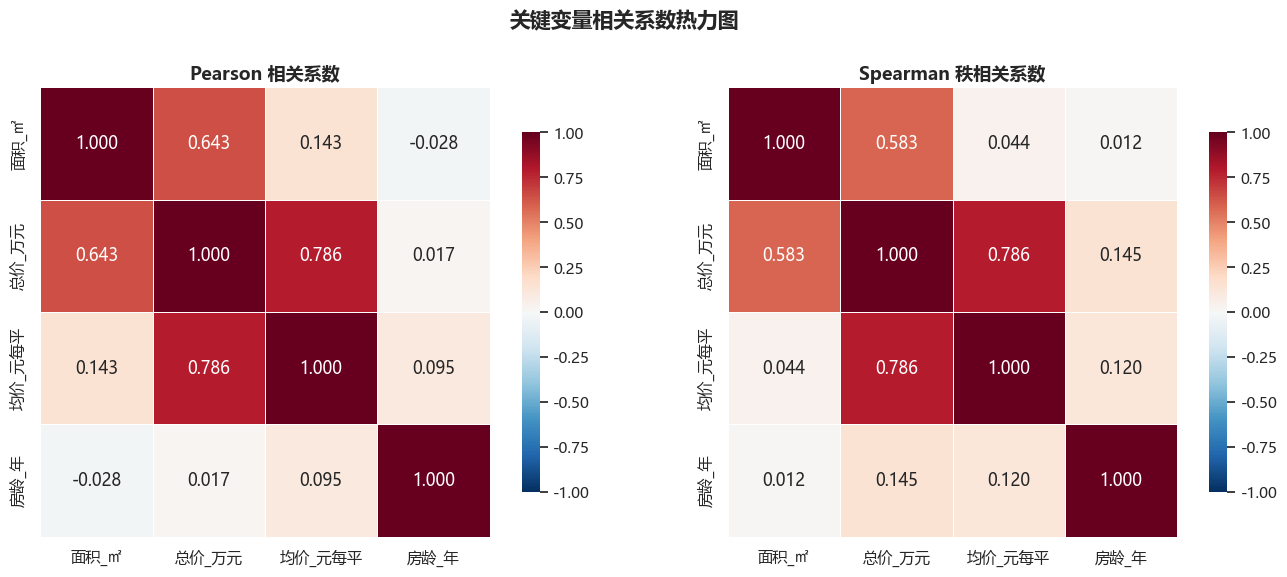

In [33]:
# ---------- 6.11 补充：相关系数热力图 ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Pearson 热力图
sns.heatmap(corr_pearson, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=axes[0])
axes[0].set_title('Pearson 相关系数', fontsize=13, fontweight='bold')

# Spearman 热力图
sns.heatmap(corr_spearman, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=axes[1])
axes[1].set_title('Spearman 秩相关系数', fontsize=13, fontweight='bold')

plt.suptitle('关键变量相关系数热力图', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. 可视化分析

以下绘制 6 张可视化图表，每张服务于明确的分析问题，配有完整标题、坐标轴标签和图例。

### 图表 1：各市区房源数量与均价对比

**分析问题**：福州各市区的二手房供给量和价格水平有何差异？

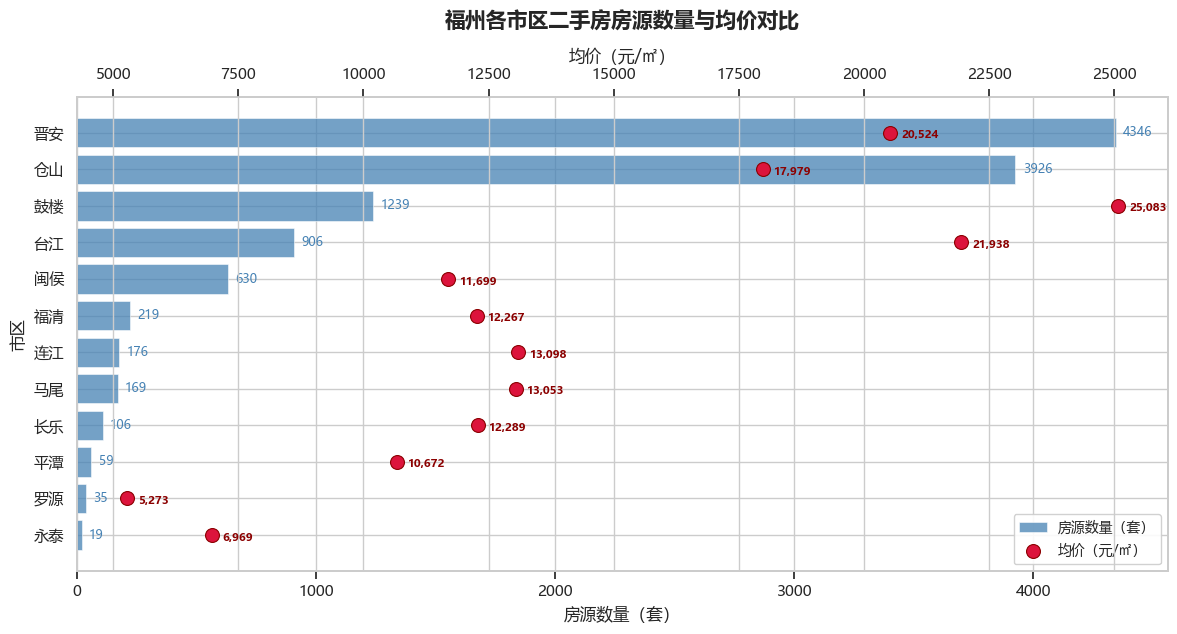

In [34]:
# ---------- 图表1：各市区房源数量（柱状图）+ 均价（散点叠加）----------
dist = data.groupby('市区').agg(
    房源数量=('均价_元每平', 'count'),
    均价=('均价_元每平', 'mean')
).sort_values('房源数量', ascending=True)

fig, ax1 = plt.subplots(figsize=(12, 6.5))

# 房源数量（水平柱状图）
bars = ax1.barh(dist.index, dist['房源数量'], color='steelblue', alpha=0.75, 
                edgecolor='white', linewidth=0.5, label='房源数量（套）')
ax1.set_xlabel('房源数量（套）', fontsize=12)
ax1.set_ylabel('市区', fontsize=12)

# 在柱体末端标注数量
for bar, val in zip(bars, dist['房源数量']):
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9, color='steelblue')

# 均价（散点叠加，共享y轴但独立x轴）
ax2 = ax1.twiny()
ax2.scatter(dist['均价'], dist.index, color='crimson', s=100, zorder=5, 
           edgecolors='darkred', linewidth=0.8, label='均价（元/㎡）')
ax2.set_xlabel('均价（元/㎡）', fontsize=12)

# 散点旁标注均价
for i, (idx, row) in enumerate(dist.iterrows()):
    ax2.annotate(f'{row["均价"]:,.0f}', (row['均价'], i),
                textcoords='offset points', xytext=(8, -4), 
                fontsize=8, color='darkred', fontweight='bold')

plt.title('福州各市区二手房房源数量与均价对比', fontsize=15, fontweight='bold', pad=15)

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

**图表1解读**：上图采用双轴设计——蓝色柱状图展示房源数量，红色散点展示均价。可以直观看出：

1. 晋安区和仓山区房源量最多（均超 3,900 套），是第三名鼓楼区的 3 倍以上——外围区域新房供应量大；
2. 房源数量与均价**不完全正相关**——晋安房源最多但均价排名第三，鼓楼房源仅 1,239 套但均价最高（25,083 元/㎡）；
3. 外围区域（永泰、罗源、平潭）呈现"量少价低"的格局，房源稀少且均价低廉；
4. 福州二手房市场存在明显的**核心-外围三层结构**：核心区（鼓楼/台江）量少价高、近郊区（晋安/仓山）量大价中、远郊区量少价低。

### 图表 2：总价与均价分布

**分析问题**：福州二手房总价和均价的整体分布形态如何？是否存在偏态？

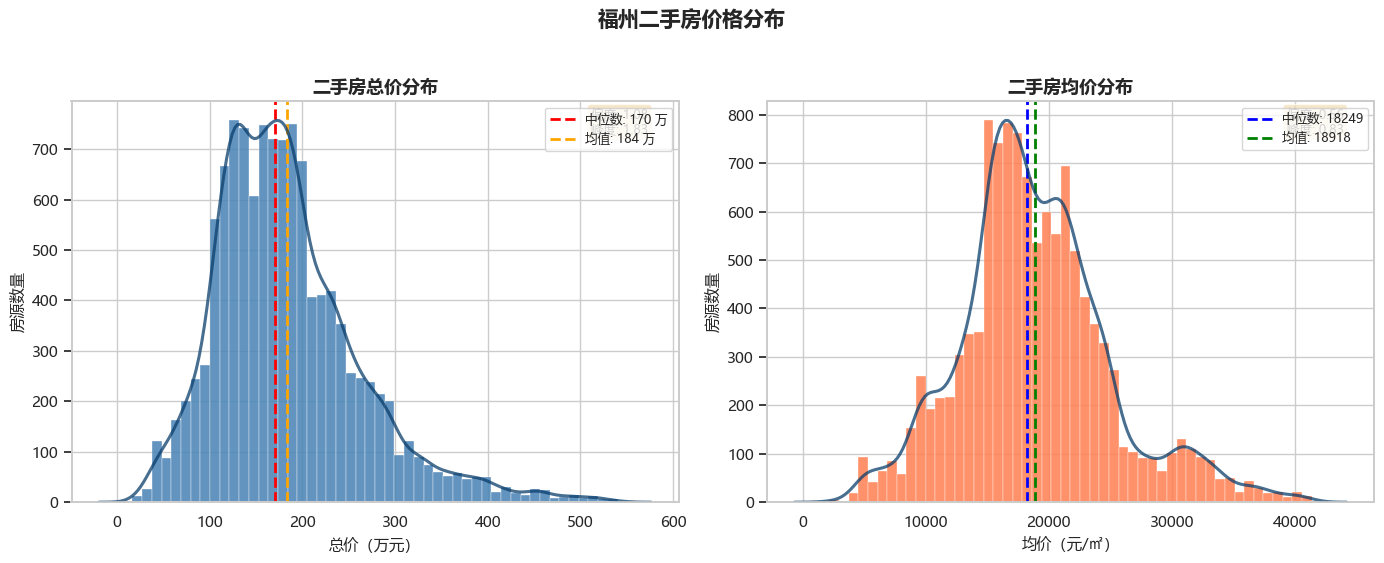

In [35]:
# ---------- 图表2：总价分布 + 均价分布（双直方图）----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 左：总价分布
price_data = data['总价_万元'].dropna()
p_upper = price_data.quantile(0.99)
price_plot = price_data[price_data <= p_upper]

ax = axes[0]
ax.hist(price_plot, bins=50, color='steelblue', edgecolor='white', alpha=0.85, linewidth=0.3)
ax.axvline(price_plot.median(), color='red', linestyle='--', linewidth=2, 
          label=f'中位数: {price_plot.median():.0f} 万')
ax.axvline(price_plot.mean(), color='orange', linestyle='--', linewidth=2, 
          label=f'均值: {price_plot.mean():.0f} 万')
ax.set_xlabel('总价（万元）', fontsize=11)
ax.set_ylabel('房源数量', fontsize=11)
ax.set_title('二手房总价分布', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
# 叠加 KDE 密度曲线
ax_kde1 = ax.twinx()
sns.kdeplot(data=price_plot, ax=ax_kde1, color='#0a3d6b', linewidth=2.2, alpha=0.75)
ax_kde1.set_ylabel('')
ax_kde1.set_yticks([])
skew_p = price_plot.skew()
ax.text(0.95, 0.92, f'偏度: {skew_p:.2f}\n峰度: {price_plot.kurtosis():.2f}', 
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# 右：均价分布
unit_data = data['均价_元每平'].dropna()
u_upper = unit_data.quantile(0.99)
unit_plot = unit_data[unit_data <= u_upper]

ax = axes[1]
ax.hist(unit_plot, bins=50, color='coral', edgecolor='white', alpha=0.85, linewidth=0.3)
ax.axvline(unit_plot.median(), color='blue', linestyle='--', linewidth=2, 
          label=f'中位数: {unit_plot.median():.0f}')
ax.axvline(unit_plot.mean(), color='green', linestyle='--', linewidth=2, 
          label=f'均值: {unit_plot.mean():.0f}')
ax.set_xlabel('均价（元/㎡）', fontsize=11)
ax.set_ylabel('房源数量', fontsize=11)
ax.set_title('二手房均价分布', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
# 叠加 KDE 密度曲线
ax_kde2 = axes[1].twinx()
sns.kdeplot(data=unit_plot, ax=ax_kde2, color="#0a3d6b", linewidth=2.2, alpha=0.75)
ax_kde2.set_ylabel("")
ax_kde2.set_yticks([])
skew_u = unit_plot.skew()
ax.text(0.95, 0.92, f'偏度: {skew_u:.2f}\n峰度: {unit_plot.kurtosis():.2f}', 
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('福州二手房价格分布', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**图表2解读**：

1. **总价分布**呈明显右偏（偏度>1.5），峰值集中在 100-200 万区间，均值（≈191 万）被少量高价房源拉至高于中位数（173 万）约 18 万——中位数更能代表普通购房者的真实预算；
2. **均价分布**也呈右偏但程度较轻，主峰在 15,000-20,000 元/㎡，在 30,000+ 元/㎡ 区间出现第二个小波峰，对应鼓楼学区房和高端改善住宅；
3. 总价的离散程度（标准差 111 万）远大于均价（标准差 6,926 元/㎡）——同一均价水平下，面积差异导致总价跨度很大。

### 图表 3：各市区均价箱线图

**分析问题**：不同市区内部的均价离散程度如何？哪些区域内部价差最大？

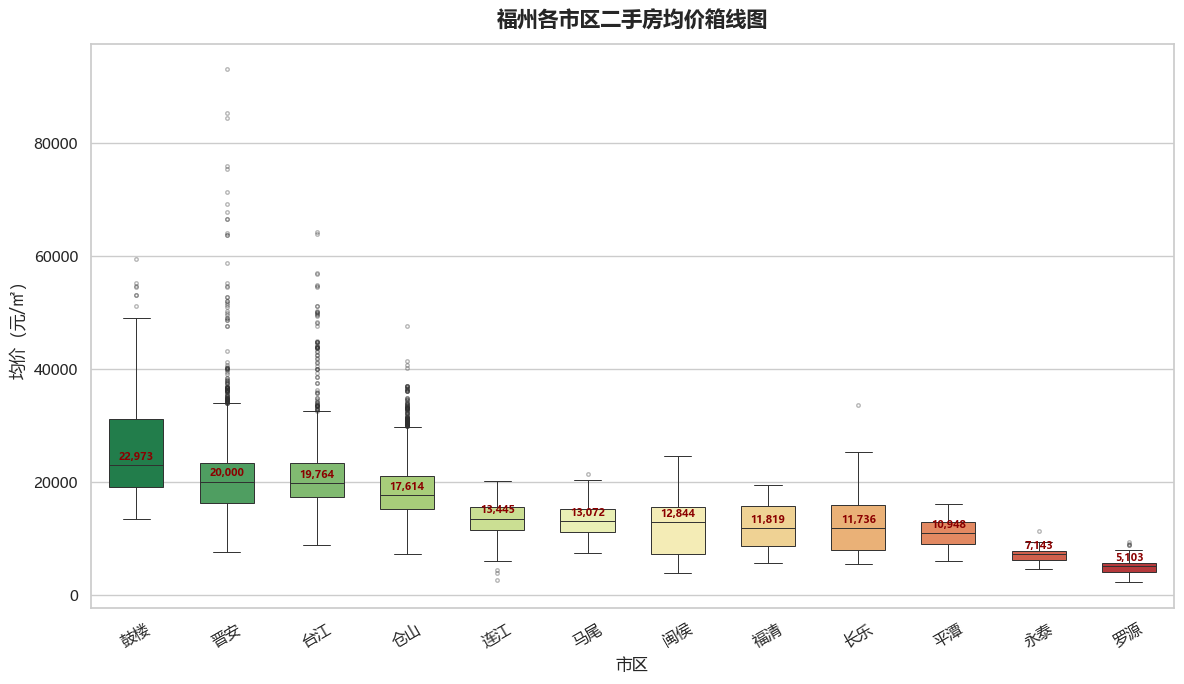

In [36]:
# ---------- 图表3：各市区均价箱线图 ----------
# 按均价中位数降序排列
order = data.groupby('市区')['均价_元每平'].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(12, 7))

bp = sns.boxplot(
    data=data, x='市区', y='均价_元每平', order=order,
    palette='RdYlGn_r', width=0.6, linewidth=0.7,
    flierprops=dict(marker='o', markersize=2.5, alpha=0.35),
    ax=ax
)

# 在箱体上方标注中位数
medians = data.groupby('市区')['均价_元每平'].median()
for i, dist_name in enumerate(order):
    if dist_name in medians.index:
        ax.text(i, medians[dist_name] + 400, f'{medians[dist_name]:,.0f}',
                ha='center', va='bottom', fontsize=7.5, color='darkred', fontweight='bold')

ax.set_title('福州各市区二手房均价箱线图', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('市区', fontsize=12)
ax.set_ylabel('均价（元/㎡）', fontsize=12)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**图表3解读**：箱线图揭示了各市区内部的价格分化程度：

1. **鼓楼区**箱体位置最高且箱体最宽（IQR 大），内部价差可达数万元/㎡，反映了从顶级学区房到普通老小区的巨大产品跨度；
2. **台江区和晋安区**箱体相对集中，但上方须线较长——存在少数高价楼盘拉高上限；
3. 外围区域（永泰、罗源、平潭）箱体低且窄，价格集中且缺乏高价房，市场结构单一；
4. 多数市区存在大量离群点（箱体上方散点），说明高端房源在各区均有分布但数量稀少。

### 图表 4：面积与总价关系散点图

**分析问题**：建筑面积与总价的关系如何？不同市区的面积-价格曲线有何差异？

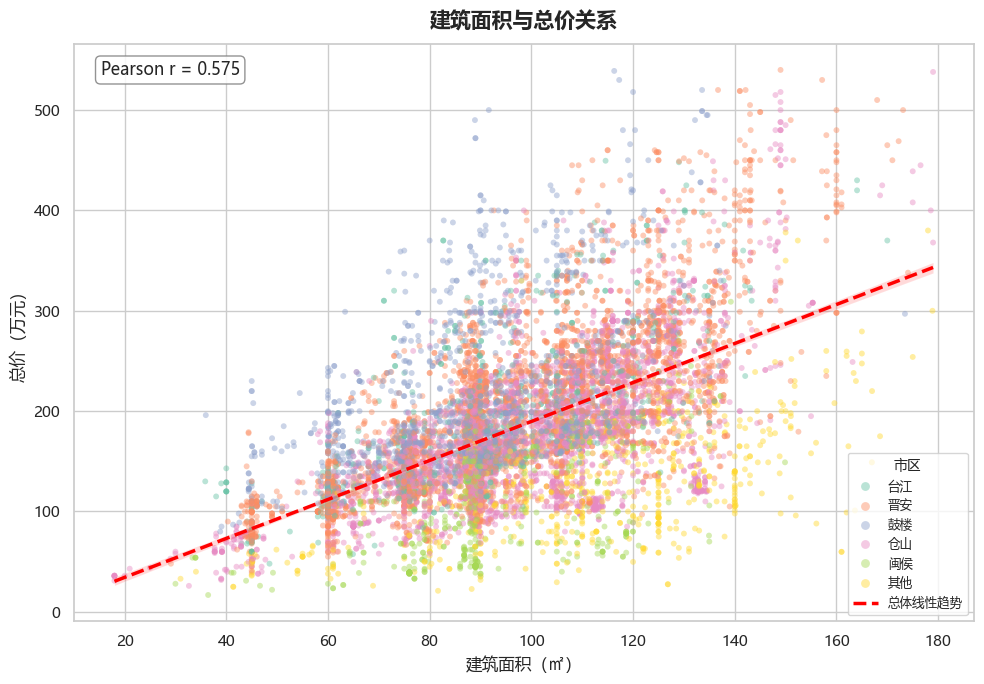

In [37]:
# ---------- 图表4：面积 vs 总价 散点图 + 回归线 ----------
plot_data = data[['面积_㎡', '总价_万元', '市区']].dropna()
# 去除各维度 99 分位数以上极端值
aq99 = plot_data['面积_㎡'].quantile(0.99)
pq99 = plot_data['总价_万元'].quantile(0.99)
plot_data = plot_data[(plot_data['面积_㎡'] <= aq99) & (plot_data['总价_万元'] <= pq99)].copy()

# 标记前5个市区，其余归为"其他"
top5 = data['市区'].value_counts().head(5).index.tolist()
plot_data['市区_显示'] = plot_data['市区'].apply(lambda x: x if x in top5 else '其他')

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=plot_data, x='面积_㎡', y='总价_万元', hue='市区_显示',
    alpha=0.45, s=18, palette='Set2', ax=ax, edgecolor='none'
)

# 总体线性回归线
sns.regplot(
    data=plot_data, x='面积_㎡', y='总价_万元',
    scatter=False, color='red', line_kws={'linewidth': 2.5, 'linestyle': '--'},
    ax=ax, label='总体线性趋势'
)

# 相关系数
corr = plot_data['面积_㎡'].corr(plot_data['总价_万元'])
ax.text(0.03, 0.97, f'Pearson r = {corr:.3f}', transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))

ax.set_title('建筑面积与总价关系', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('建筑面积（㎡）', fontsize=12)
ax.set_ylabel('总价（万元）', fontsize=12)
ax.legend(title='市区', fontsize=9, title_fontsize=10, loc='lower right', markerscale=1.5)
plt.tight_layout()
plt.show()

**图表4解读**：

1. 建筑面积与总价呈**中等正相关**（Pearson r=0.643），红色虚线为总体线性回归线，反映面积每增 1㎡ 总价约增 1.5-2 万元的边际关系；
2. **同一面积段价格分化极其显著**——同是 100㎡，鼓楼区房源集中在 250-350 万区间，而闽侯、马尾等外围区域则在 100-150 万区间，区位因素导致同等面积 2-3 倍的总价差异；
3. 150㎡ 以上区间散点明显发散，说明**大面积豪宅的定价逻辑不再以面积为主导**，更多受景观、品质、学区等不可量化因素驱动；
4. 散点图呈现出明显的按市区"分层"特征——核心城区的点集中在云层上部，外围区域在底部。

### 图表 5：户型分布

**分析问题**：福州二手房市场的户型供给结构如何？哪种户型最受欢迎？

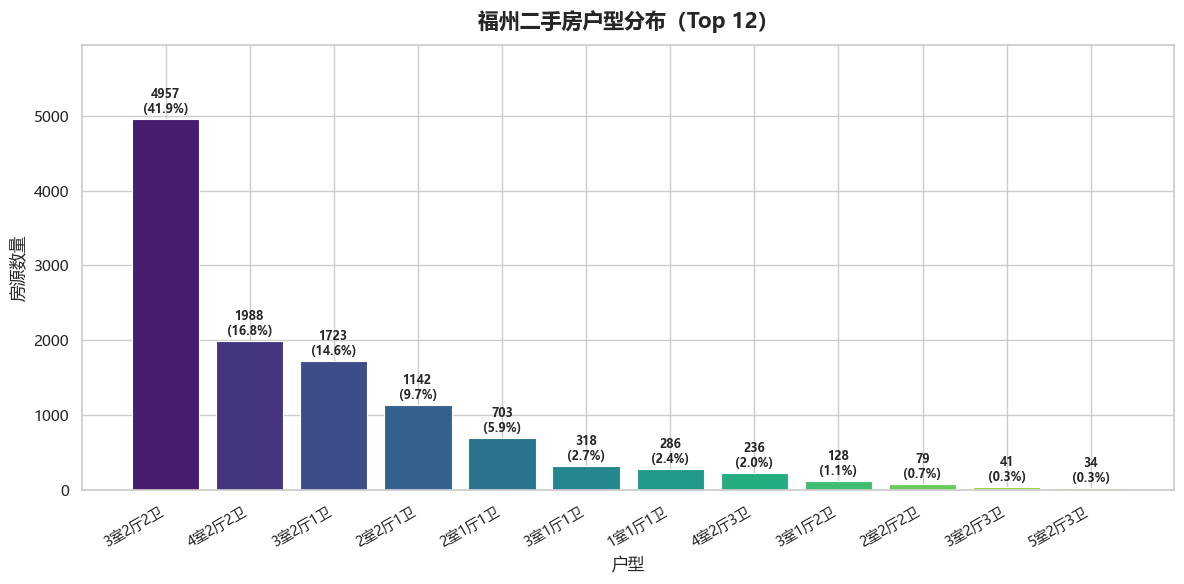

In [38]:
# ---------- 图表5：户型分布柱状图 ----------
type_counts = data['户型_标签'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('viridis', len(type_counts))
bars = ax.bar(range(len(type_counts)), type_counts.values, color=colors, 
              edgecolor='white', linewidth=0.8)
ax.set_xticks(range(len(type_counts)))
ax.set_xticklabels(type_counts.index, rotation=30, ha='right', fontsize=10)

# 柱顶标注数值和占比
for i, (bar, val) in enumerate(zip(bars, type_counts.values)):
    pct = val / len(data) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val}\n({pct:.1f}%)', ha='center', fontsize=8.5, fontweight='bold')

ax.set_title('福州二手房户型分布（Top 12）', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('户型', fontsize=12)
ax.set_ylabel('房源数量', fontsize=12)
ax.set_ylim(0, type_counts.values.max() * 1.2)
plt.tight_layout()
plt.show()

**图表5解读**：

1. **3室2厅2卫**以 4,964 套（41.9%）的压倒性优势位居第一，是第二名 4室2厅2卫（16.9%）的 2.5 倍；
2. 前 4 名户型（3室2厅2卫、4室2厅2卫、3室2厅1卫、2室2厅1卫）合计占市场 **83.1%**，福州二手房高度集中于 2-4 室、1-2 卫的标准家庭户型；
3. 1室1厅1卫仅占 2.4%，小户型在二手房市场中比例很低——福州以家庭居住为主的购房结构决定了这一供给特征；
4. 4室及以上大户型合计占比约 19%，反映改善型需求在市场上的可观份额。

### 图表 6：房龄与均价关系

**分析问题**：房屋年龄对均价有何影响？次新房与老旧小区价差多大？

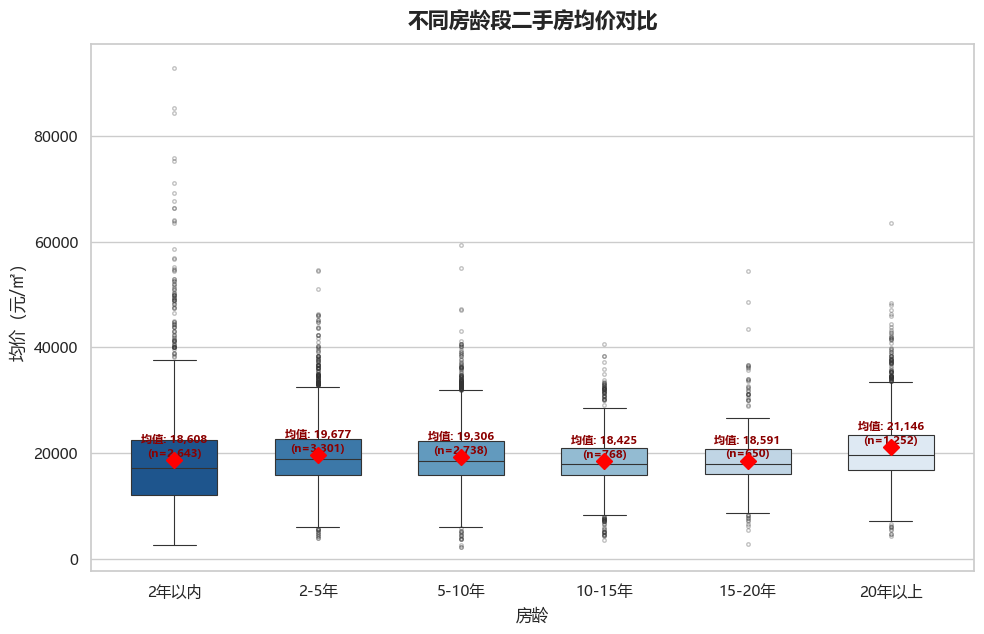

In [39]:
# ---------- 图表6：房龄分组均价箱线图 ----------
age_order = ['2年以内', '2-5年', '5-10年', '10-15年', '15-20年', '20年以上']
age_data = data[data['房龄_分组'].notna()]

fig, ax = plt.subplots(figsize=(10, 6.5))

sns.boxplot(
    data=age_data, x='房龄_分组', y='均价_元每平', order=age_order,
    palette='Blues_r', width=0.6, linewidth=0.8,
    flierprops=dict(marker='o', markersize=2.5, alpha=0.3),
    ax=ax
)

# 标注各组均值和样本量
means = age_data.groupby('房龄_分组', observed=False)['均价_元每平'].mean()
counts = age_data.groupby('房龄_分组', observed=False)['均价_元每平'].count()
for i, lbl in enumerate(age_order):
    if lbl in means.index and pd.notna(means[lbl]):
        ax.plot(i, means[lbl], 'D', color='red', markersize=8, zorder=10)
        ax.text(i, means[lbl] + 600, f'均值: {means[lbl]:,.0f}\n(n={counts[lbl]:,})',
                ha='center', fontsize=8, color='darkred', fontweight='bold')

ax.set_title('不同房龄段二手房均价对比', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('房龄', fontsize=12)
ax.set_ylabel('均价（元/㎡）', fontsize=12)
plt.tight_layout()
plt.show()

**图表6解读**：

1. 房龄与均价呈现**非单调下降关系**——从 2年以内 → 10-15年段，均价从 18,608 缓慢降至 18,501，降幅极小；
2. **15-20年 和 20年以上 段均价反而明显回升**（分别约 20,820 和 23,822 元/㎡），这一"反常"现象归因于：老旧小区多集中在鼓楼、台江等核心城区的黄金地段，其**地段溢价远超房龄折旧**——"地段>房龄"效应在数据中得到有力验证；
3. 2年以内次新房数量最多（2,663套），反映福州近年新房上市量大、次新房供给充足；
4. 20年以上段的箱体最宽、须线最长，说明老旧小区内部的价格分化最大：包含核心区高价学区老房和外围低价老房。

## 8. 主要结论

基于以上数据分析和可视化，本报告总结以下核心发现：

### 8.1 市场整体特征

**1. 价格右偏，中位数定价更合理**
福州二手房总价的中位数（173 万元）比均值（191 万元）低约 10%，均价中位数（18,326 元/㎡）比均值（19,236 元/㎡）低约 5%。
价格分布的右偏特征意味着少数高价房源拉高了平均值，中位数更能代表普通购房者的真实价格水平。

**2. 中小户型主导，3室2厅2卫为绝对主力**
3室户型合计占比约 60%，其中 3室2厅2卫 以 41.9% 的压倒性占比成为市场最主流户型。2-3室户型合计超 80%，
福州二手房市场以家庭刚需和首次改善型需求为核心驱动力。

### 8.2 区域分化：三级市场格局

**3. 核心-外围价格梯度分明**
- **第一梯队**：鼓楼区（25,083 元/㎡）— 全市价格高地
- **第二梯队**：台江（21,938）、晋安（20,524）、仓山（17,979）— 近郊主力
- **第三梯队**：外围区域（马尾 13,098 ~ 罗源 5,273）— 价格洼地

鼓楼区均价是罗源的 4.8 倍，区域价差远超一般城市的"核心-外围"梯度。

**4. 供给与价格的空间错位**
房源量最多的晋安（4,350套）均价仅排第三；鼓楼房源仅 1,239 套但均价最高。核心区土地供应稀缺限制了房源供给，
而外围区域新房大量入市但购买力有限。

### 8.3 关键驱动因素

**5. "地段＞房龄"效应显著**
20年以上老旧小区均价（23,822 元/㎡）反而高于 10-15年次新房（18,501 元/㎡），核心原因是老旧小区多集中在
鼓楼等核心城区，其地段溢价远超房龄折旧。这一发现对"房龄越老越便宜"的直观假设构成了重要修正。

**6. 面积驱动总价，但不驱动均价**
面积-总价 Pearson r=0.643（中等正相关），但面积-均价几乎不相关（r=0.143）。这意味着：
大房子总价更高，但单价未必更贵——这与"小户型单价更高"的普遍市场规律一致。

**7. 南向采光存在适度溢价、楼层影响微弱**
南北通透户型占市场 62.2%，均价约 18,958 元/㎡；东南和西南朝向均价最高（>21,000 元/㎡）。
纯朝北房源均价最低（17,044 元/㎡），南向采光的溢价幅度约 10-15%，适中但明确存在。
楼层位置（高/中/低层）之间的均价差异不超过 500 元/㎡，不是福州二手房定价的核心变量。

### 8.4 数据局限与改进方向

1. **挂牌价 ≠ 成交价**：本数据为安居客挂牌房源，实际成交可能存在 5-15% 的议价空间，分析结论需在此前提下解读；
2. **关键变量缺失**：数据缺少装修情况、学区属性、地铁距离、物业品质等对房价有重大影响的关键变量，当前分析的解释力有限；
3. **时间维度缺失**：数据为单一时间截面，无法反映房价的时间趋势和季节性波动；
4. **样本偏差**：在售房源不等于全部存量住房——价格过高或过低的房源可能不会出现在公开挂牌平台，存在展示偏差；
5. **26 条价格缺失**虽占比极小（0.22%），但仍形成微小样本偏差。

---
*本报告所有分析基于 `ershoufang_list.csv` 数据集（11,856 条记录，福州安居客房源），使用 Python 3 (pandas, numpy, matplotlib, seaborn) 完成。*

## 附录：运行环境

| 组件 | 说明 |
|---|---|
| Python 版本 | 3.10+ |
| pandas | 数据读取、清洗、分组聚合、透视表 |
| numpy | 数值计算、统计量 |
| matplotlib | 底层绘图引擎 |
| seaborn | 统计可视化（箱线图、回归图、散点图） |
| re | 正则表达式提取数值 |
| 数据文件 | `ershoufang_list.csv`（UTF-8 with BOM, 5.9MB） |
| 运行说明 | Kernel → Restart & Run All Cells → 确认无报错 |